In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import PIL
import os
from pathlib import Path
import sys
sys.path.append("../")
import utils as ut
import seaborn as sns
import pandas as pd
from matplotlib.colors import ListedColormap, Colormap
import matplotlib.patches as patches
from matplotlib.patches import Patch
import yaml

In [ ]:
def plot_predictions(df, pred_labels, color_map, ax, alpha=0.8):
    """Helper function for plotting predictions without plate-wise styling"""
    for pred_label in pred_labels:
        for _, group in df.groupby('Metadata_Well'):
            smoothed_values = ut.noise_reduction(group[pred_label].values)
            df.loc[group.index, f'smoothed_{pred_label}'] = smoothed_values
        
        sns.lineplot(data=df,
                    x='Metadata_hours',
                    y=f'smoothed_{pred_label}',
                    label=pred_label,
                    errorbar='sd',
                    ax=ax,
                    color=color_map[pred_label],
                    alpha=alpha)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())


array(['F10', 'H3', 'I15', 'K17', 'P19', 'D14', 'F18', 'J20', 'M24',
       'N22'], dtype=object)

A549-WT
Plate: P106068
LY2228820 well: ['A12', 'E20', 'K10', 'O8', 'P16']
Plate: P106073
LY2228820 well: ['F10', 'H3', 'I15', 'K17', 'P19']
Plate: P106076
LY2228820 well: ['D14', 'F18', 'J20', 'M24', 'N22']
U2OS-WT
Plate: P106071
LY2228820 well: ['F10', 'H3', 'I15', 'K17', 'P19']
Plate: P106077
LY2228820 well: ['D14', 'F18', 'J20', 'M24', 'N22']
Plate: P106079
LY2228820 well: ['D14', 'F18', 'J20', 'M24', 'N22']


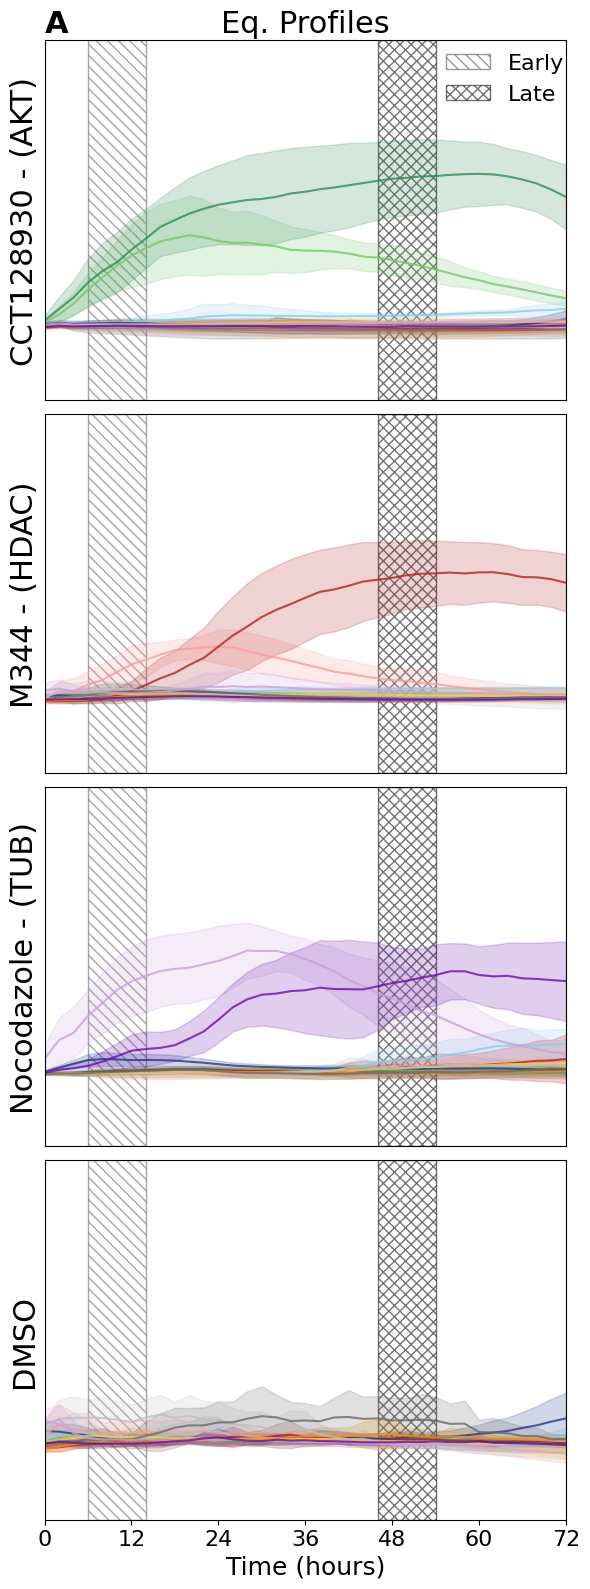

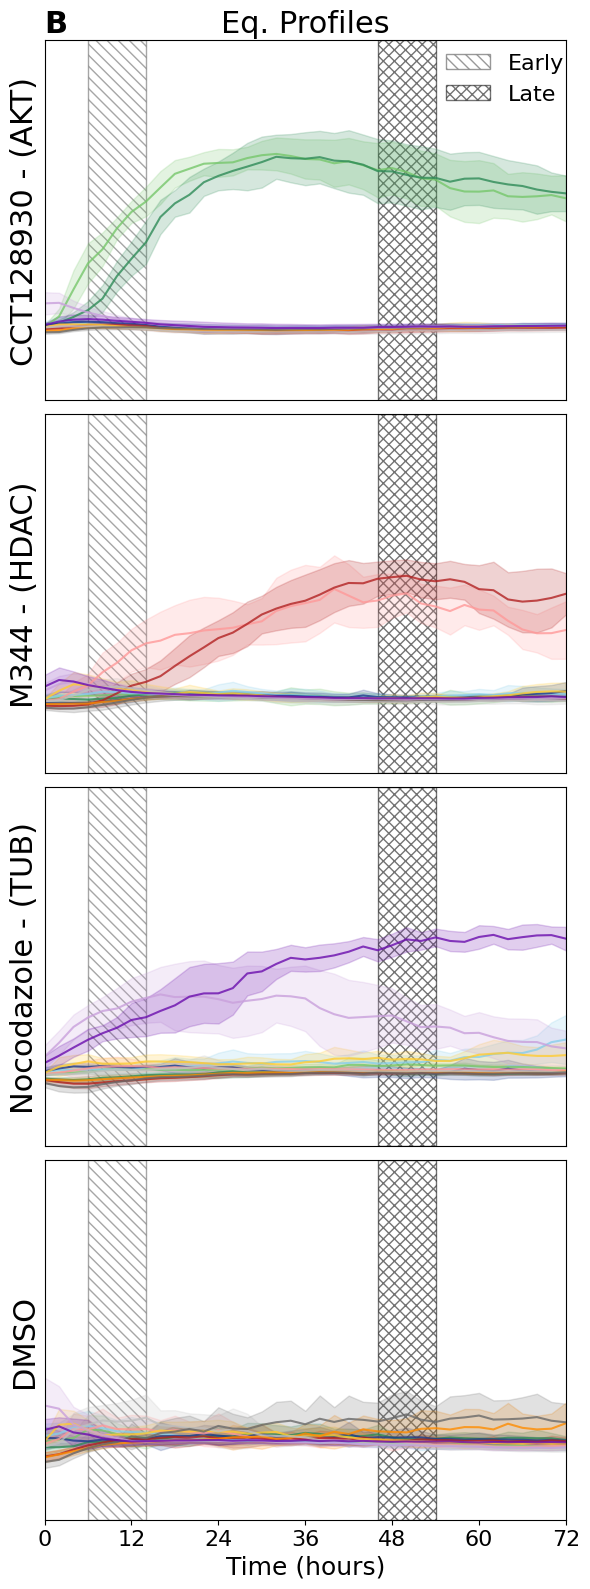

In [ ]:
cells = ['A549-WT', 'U2OS-WT']
# Define the colors
colors = [
    "#76c76b", "#2e8b57",  # Adjusted light and dark green
    "#87ceeb", "#1e3a8a",  # Adjusted light and slightly brighter dark blue
    "#ff9999", "#b22222",  # Adjusted light and slightly brighter dark red
    "#ffcc33", "#ff8c00",  # Adjusted light and dark yellow/orange
    "#bfbfbf", "#696969",  # Adjusted light and dark gray
    "#c9a0dc", "#6a0dad"   # Adjusted light and slightly brighter dark purple
]
# Create the categorical colormap
cmap = ListedColormap(colors)
cells = ['A549-WT', 'U2OS-WT']

dir_pointer = "../../"
for ncell, cell in enumerate(cells):
    config_path = f"{cell}-analysis-datapaths.yaml"
    print(cell)
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    # Load data    
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    ab = ['A', 'B']
    fontsize = 22

    save_dir = dir_pointer
    # Load data
    cmpd_df = dir_pointer + config['time_series']['time_series_analysis']
    dmso_df = dir_pointer + config['time_series']['time_series_analysis_dmso']
    cmpd_df = pd.read_parquet(cmpd_df)
    dmso_df = pd.read_parquet(dmso_df)

    moas = [moa for moa in cmpd_df.Metadata_cmpd_moa_group.unique().tolist() if (moa and 'dmso' not in str(moa))]
    moas.sort()
    flatten_pred_labels = [f'{c}_pred_{t}'  for c in moas for t in ['early', 'late']]
    
    compounds = ["CCT128930", "M344", "Nocodazole", "dmso"]
    both_wells = [["B21", "F17", "H17", "D17"], ["C11", "M5", "P7", "G13"]]
    wells = both_wells[ncell]
    # sub_fig_sums, axes_sums = plt.subplots(len(compounds), 1, figsize=(6, 16))
    
    sub_fig, axes = plt.subplots(len(compounds), 1, figsize=(6, 16))
    color_map = {label: cmap(i) for i, label in enumerate(flatten_pred_labels)}
    for i, compound_well in enumerate(zip(compounds, wells)):
        compound, well = compound_well
        ax = axes[i]
        if compound == "dmso":
            sort_df = dmso_df
        else:
            sort_df = cmpd_df[cmpd_df.Metadata_cmpd_oldcmpdname == compound].copy()
        sort_df['Metadata_hours'] = pd.to_numeric(sort_df['Metadata_hours'], errors='coerce')
        sort_df = sort_df.dropna(subset=['Metadata_hours']).sort_values('Metadata_hours')
        sort_df = sort_df[sort_df.Metadata_hours <= 72]
       
        # Add striped "early" region
        early_patch = patches.Rectangle(
            (6, -0.5), 
            8,         
            2.5,       
            facecolor='none',
            hatch='\\\\\\',
            # hatch='///',
            edgecolor='grey',
            linewidth=1,
            zorder=0,
            alpha=0.7
        )
        ax.add_patch(early_patch)

        # Add striped "late" region
        late_patch = patches.Rectangle(
            (46, -0.5),
            8,
            2.5,
            facecolor='none',
            # hatch='\\\\\\',
            hatch='xxx',
            edgecolor='black',
            linewidth=1,
            zorder=0,
            alpha=0.55
        )
        ax.add_patch(late_patch)
        
        plot_predictions(sort_df, flatten_pred_labels, color_map, ax)
        #Remove legend
        ax.get_legend().remove()
        ax.set_xlim((0, 72))
        ax.set_ylim((-0.5, 2))        
        # Set consistent xticks
        ax.set_xticks([0, 12 ,24, 36, 48, 60, 72])    
    
        if compound == "dmso":
            compound = "DMSO"
            ax.set_ylabel(f'{compound}', fontsize=fontsize)
        else:
            ax.set_ylabel(f'{compound} - ({sort_df.Metadata_cmpd_moa_group.unique()[0]})', fontsize=fontsize)
        if i == 0:
            ax.set_title('Eq. Profiles', fontsize=fontsize)
            ax.set_title(f'{ab[ncell]}', fontsize=fontsize, loc='left', fontweight='bold')
        if i == 3:
            # ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
            ax.set_xlabel('Time (hours)', fontsize=18)
            ax.tick_params(axis='x', labelsize=16)
        else:
            ax.set_xlabel('')
            ax.set_xticklabels([])
            ax.set_xticks([])

        # Custom legend handles for the hatched areas
        early_legend = Patch(
            facecolor='none',
            edgecolor='grey',
            hatch='\\\\\\',
            label='Early',
            linewidth=1,
            alpha=0.8
        )

        late_legend = Patch(
            facecolor='none',
            edgecolor='black',
            hatch='xxx',
            label='Late',
            linewidth=1,
            alpha=0.55
        )

        # Add legend
        if i == 0:
            ax.legend(handles=[early_legend, late_legend], loc='upper right', bbox_to_anchor=(1.035, 1.02), fontsize=16, frameon=False)

        ax.set_yticklabels([])
        ax.set_yticks([])
    plt.tight_layout(h_pad=1)
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/{cell}_eq_profiles.svg', bbox_inches='tight')
    

A549


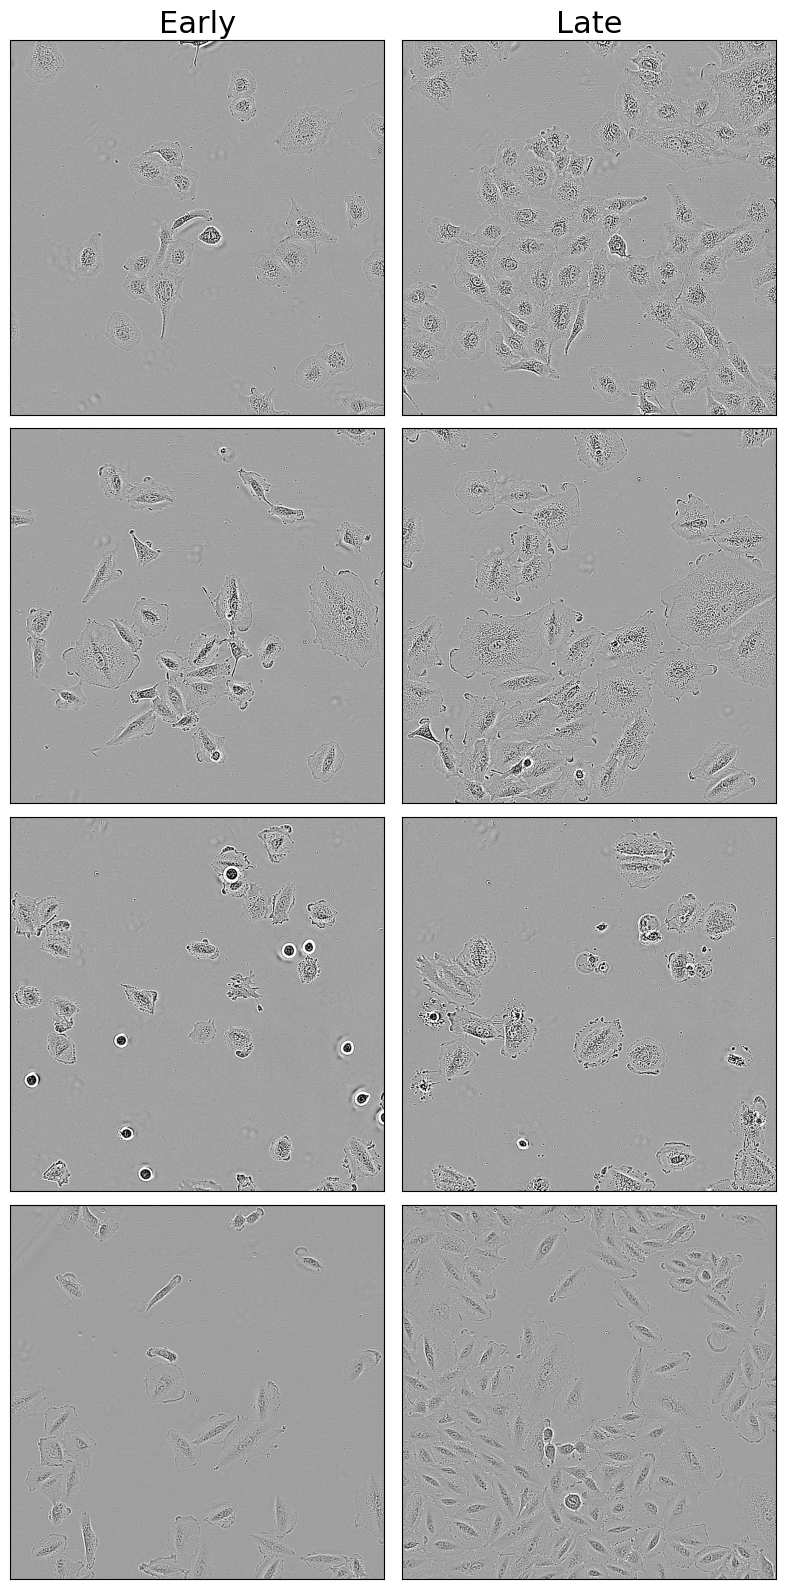

U2OS


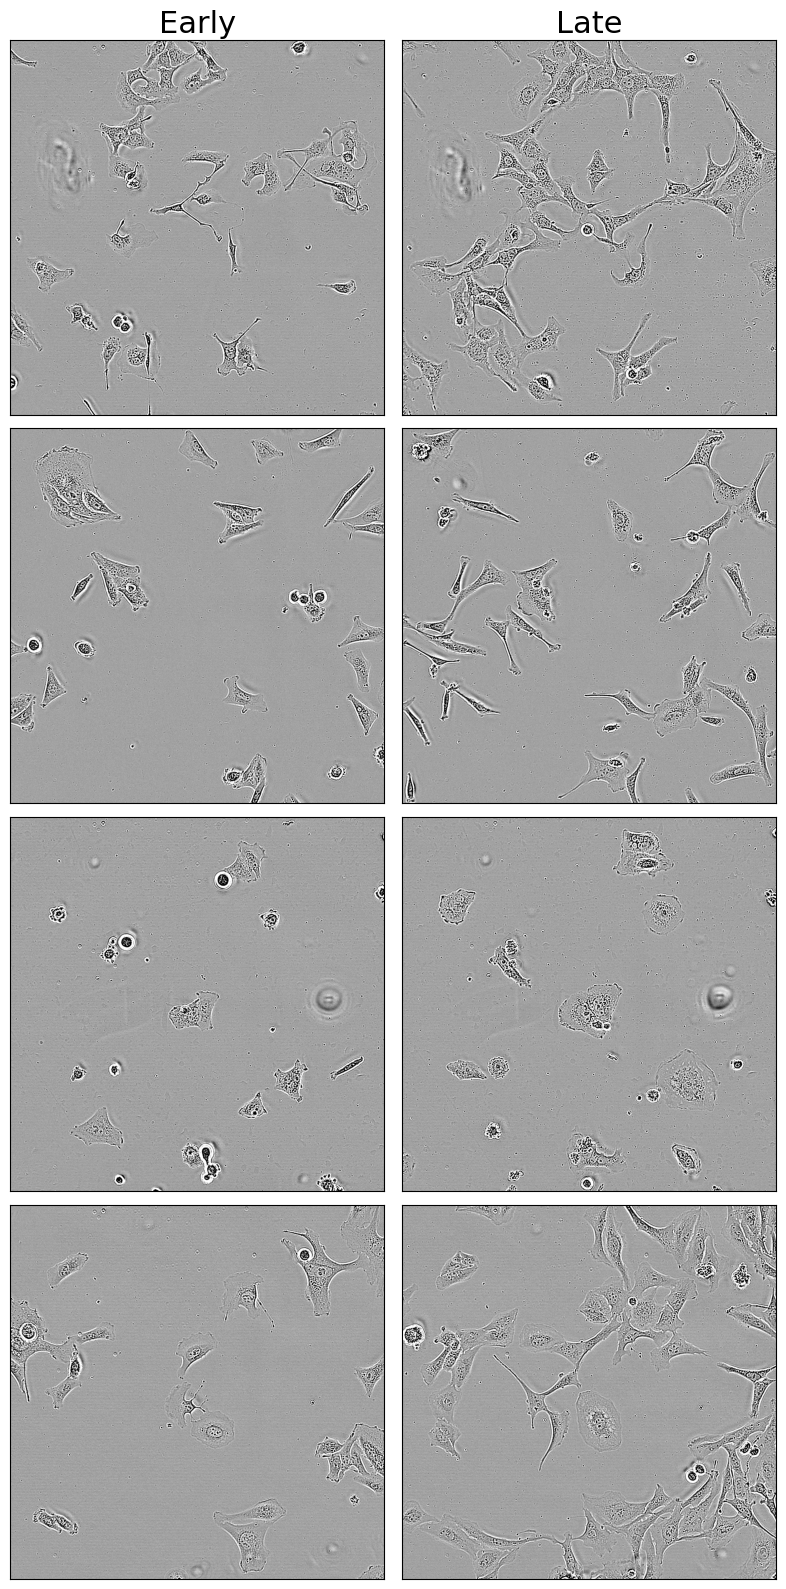

In [9]:
cells = ['A549', 'U2-OS']
cells_ax = ['A549', 'U2OS']
split_cond = [' ', '_']
moas = ['', '(AKT)', '(HDAC)', '(TUB)']

sort_moas = sorted(moas)
i = 0
img_size = 500
title_size = 22
for cell in cells_ax:
    sub_fig, axes = plt.subplots(4, 2, figsize=(8, 16))
    axes = axes.flatten()
    dir_path = os.path.join(f"../plot_data/cell_images/Cell_images_{cell}_8h_48h/")
    print(cell)
    j = 0
    for (root, dirs, figs) in os.walk(dir_path):
        figs = [fig for fig in figs if fig.endswith('.tif')]
        figs.sort()
        # Move figs contains "DMSO" to the front
        for (root, dirs, figs) in os.walk(dir_path):
            figs = [fig for fig in figs if fig.endswith('.tif')]
            figs.sort()
            # Move figs containing "DMSO" to the end of the list
            figs = [fig for fig in figs if 'DMSO' not in fig] + [fig for fig in figs if 'DMSO' in fig]
        
        for fig in figs:
            if fig.split(' ')[0].startswith('U2'):
                title_name = fig.split(' ')[1]
            else:
                title_name = fig.split(' ')[0]
            if title_name == 'CCT':
                title_name = 'CCT128930'
            if j % 2 == 0:
                hour = '8h'
                timepoint = 'Early'
            else:
                hour = '48h'
                timepoint = 'Late'
            img = Image.open(Path(os.path.join(dir_path, fig)))
            img = np.array(img)
            img = img[:,:,0]
            img = img[0:2*img_size, 0:2*img_size]
            axes[j].imshow(img, cmap='gray')
            axes[j].set_xticks([])
            axes[j].set_yticks([])
            moa_ind = int(np.floor(j // 2))
            if j < 2:
                axes[j].set_title(timepoint, fontsize=title_size)
            j += 1
    i += 1
    plt.tight_layout(h_pad=1, w_pad=2)
    plt.savefig(f'figures/{cell}_cell_images_8h_48h.svg', format='svg', bbox_inches='tight')
    plt.show()

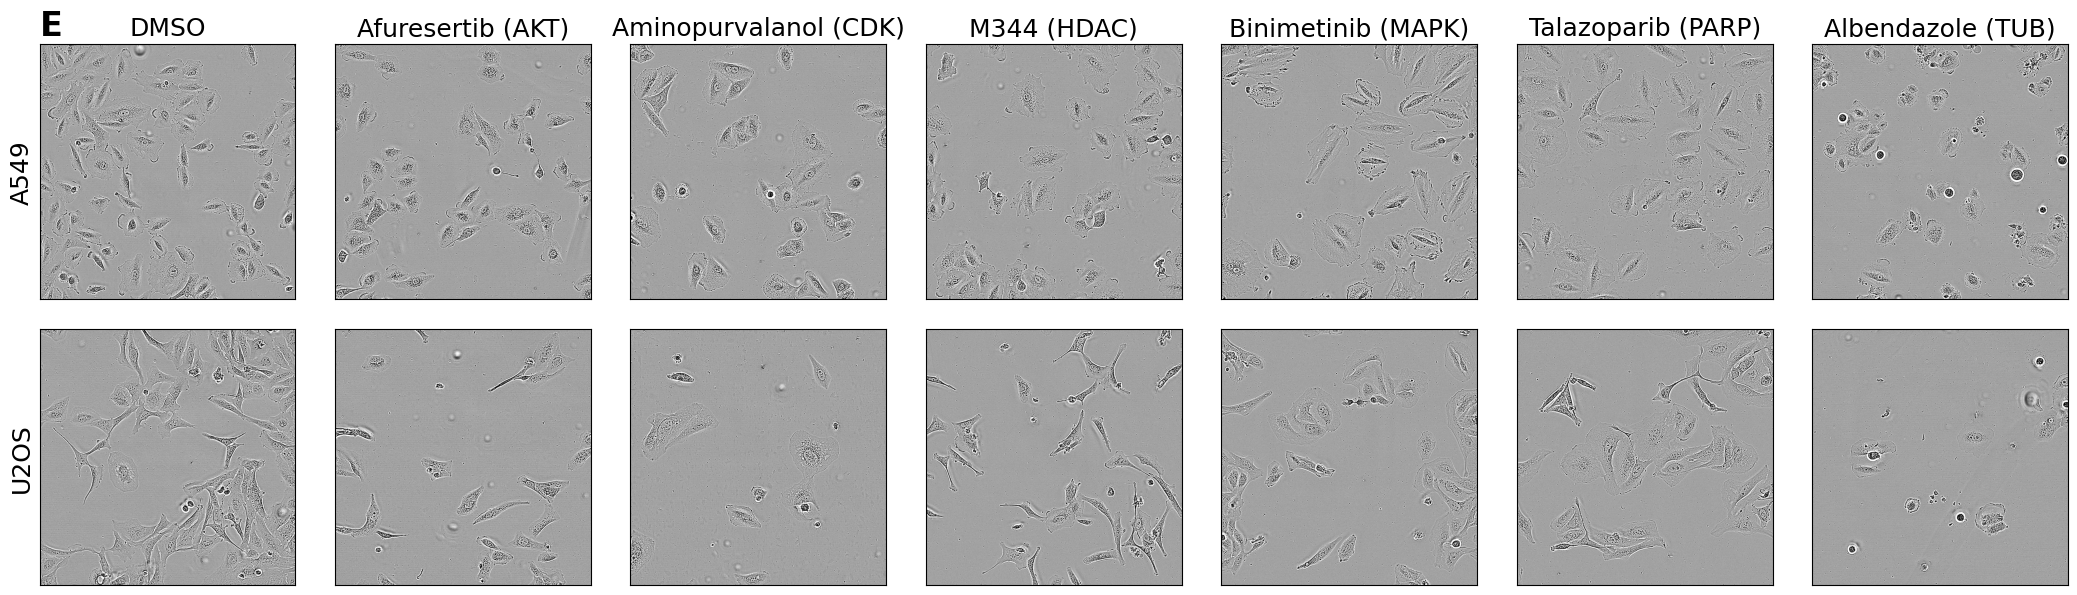

In [7]:
dir_paths = ['../plot_data/Figure 2', '../plot_data/Figure 3']
cells = ['A549', 'U2-OS']
cells_ax = ['A549', 'U2OS']
split_cond = [' ', '_']
moas = ['(AKT)', '(TUB)', '(CDK)', '(MAPK)', '(HDAC)', '(PARP)', '']
sort_moas = sorted(moas)
fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes = axes.flatten()
i = 0
img_size = 512
title_size = 18
for dir_path in dir_paths:
    for (root, dirs, figs) in os.walk(dir_path):
        j = 0
        figs = [fig for fig in figs if fig.endswith('.tif') and not fig.startswith(f'{cells[i]}')]
        figs.sort()
        for fig in figs:
            if fig.endswith('.tif') and not fig.startswith(f'{cells[i]}'):
                img_ind = moas.index(sort_moas[j])
                fig = figs[img_ind]
                img = Image.open(f'{dir_path}/{fig}')
                img = np.array(img)
                img = img[:,:,0]
                mid_x, mid_y = int(img.shape[0]/2), int(img.shape[1]/2)
                
                img = img[mid_x-img_size:mid_x+img_size, mid_y-img_size:mid_y+img_size]
                axes[i*7+j].imshow(img, cmap='gray')
                # remove x and y ticks
                axes[i*7+j].set_xticks([])
                axes[i*7+j].set_yticks([])
                if j == 0:
                    axes[i*7+j].set_ylabel(cells_ax[i], fontsize=title_size)
                if i == 0:
                    if fig.split(f'{split_cond[i]}')[0] == 'Vehicle':
                        axes[i*7+j].set_title('DMSO', fontsize=title_size)
                        axes[i*7+j].set_title('E', fontsize=24, fontweight='bold', loc='left')
                    else:
                        axes[i*7+j].set_title(fig.split(f'{split_cond[i]}')[0] + ' ' + moas[img_ind], fontsize=title_size)
                    
                j += 1
    i += 1
plt.tight_layout(h_pad=3, w_pad=2)
plt.savefig('figures/all_cell_images.svg', format='svg')

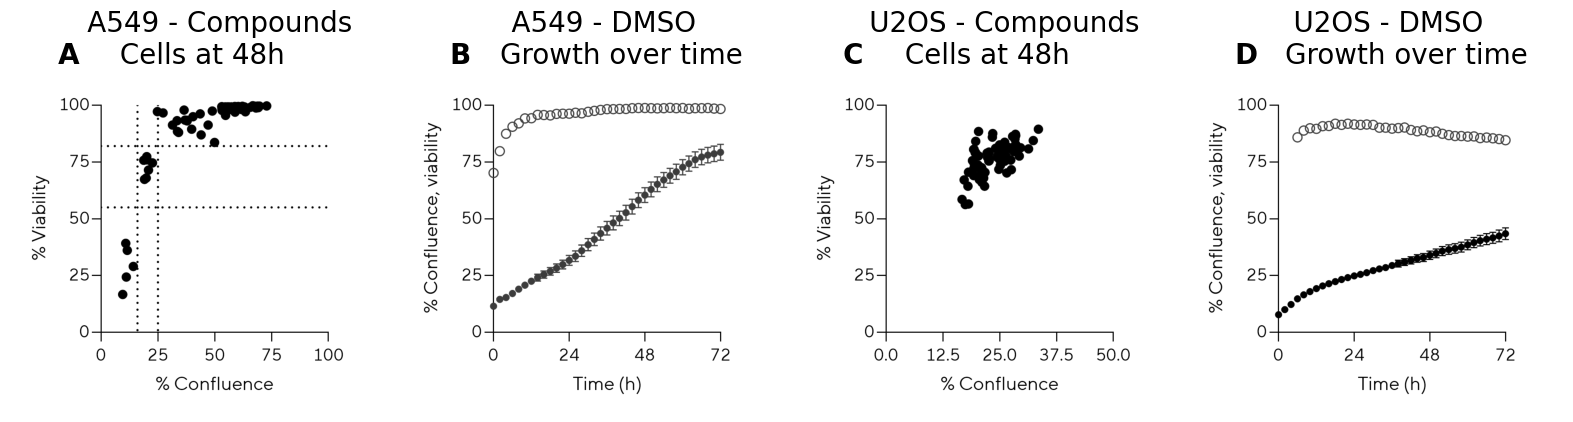

In [8]:
dir_paths = ['../plot_data/Figure 2', '../plot_data/Figure 3']
cells = ['A549', 'A549', 'U2-OS', 'U2-OS']
cells_ax = ['A549','A549', 'U2OS', 'U2OS']
split_cond = [' ']
moas = ['(AKT)', '(TUB)', '(CDK)', '(MAPK)', '(HDAC)', '(PARP)', '']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()
i = 0
img_size = 512
title_size = 20
ABCD_list = ['A', 'B', 'C', 'D']
for dir_path in dir_paths:
    for (root, dirs, figs) in os.walk(dir_path):
        figs.sort()
        for fig in figs:
            if i >3:
                break
            if fig.endswith('.tif') and fig.startswith(f'{cells[i]}'):
                img = Image.open(f'{dir_path}/{fig}')
                img = np.array(img)
                axes[i].imshow(img, cmap='gray')
                axes[i].axis('off')
                # remove x and y ticks
                axes[i].set_xticks([])
                axes[i].set_yticks([])
                axes[i].set_title(f'     {ABCD_list[i]}', fontsize=title_size, fontweight='bold', loc='left')
                if i % 2 == 1:
                    axes[i].set_title(f'    {cells_ax[i]} - DMSO \n       Growth over time', fontsize=title_size)
                else:
                    axes[i].set_title(f'      {cells_ax[i]} - Compounds \n Cells at 48h', fontsize=title_size)
                    
                i += 1
plt.tight_layout(h_pad=0, w_pad=0)
plt.savefig('figures/cell_viability_confluence.svg', format='svg', bbox_inches='tight')